In [1]:
%matplotlib inline

import os, sys, warnings, pickle
from pathlib import Path

ROOT = Path.cwd()
os.chdir(ROOT)

import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import scipy.sparse as sp
from pathlib import Path
from plots import set_nature_style
set_nature_style()

warnings.filterwarnings("ignore", category=FutureWarning)
sys.path.insert(0, "..")

# ── Paths ────────────────────────────────────────────────────────────────────
DATA_PROC    = Path("data/processed")
RESULTS_DIR  = Path("Results/stgp")
FIGURES_DIR  = Path("Figures/Immune_L")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
CELLTYPE = "Immune"   

In [2]:
adata_immune = sc.read_h5ad(DATA_PROC / f"{CELLTYPE}.h5ad")
adata_immune.obs['side'] = adata_immune.obs.ident.astype(str).str[-1]
adata_immune = adata_immune[adata_immune.obs['injury_time_days'] > 0].copy()
adata_immune = adata_immune[adata_immune.obs['side'] == 'L'].copy()
adata_immune.obs['age'] = adata_immune.obs['injury_time_days'].copy()
adata_immune

AnnData object with n_obs × n_vars = 27808 × 299
    obs: 'x_centroid', 'y_centroid', 'n_genes', 'n_counts', 'ident', 'region', 'celltype_plot', 'time', 'CN', 'injury_time_days', 'side', 'age'
    uns: 'CN_colors', 'celltype_plot_colors', 'ident_colors', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap', 'spatial'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [3]:
import time
from stgp.estimation import fit_pfactor_auto, fit_pfactor
from stgp.kernels import (
    bandwidth_select_spatial, bandwidth_select_temporal,
    build_K_age, build_K_spa_list_from_stacked
)
from stgp.preprocessing import standardize_coords_list, log1p_norm_centered_list

OUT_DIR = RESULTS_DIR / "Immune_L"
OUT_DIR.mkdir(parents=True, exist_ok=True)
PKL_PATH = OUT_DIR / "stgp_result.pkl"

age_arr = adata_immune.obs["injury_time_days"]
groups  = adata_immune.obs["ident"].astype(str)
uniq, inv = np.unique(groups, return_inverse=True)
idx_per_group = [np.sort(np.where(inv == t)[0]) for t in range(len(uniq))]

adata_prep = adata_immune.copy()
sc.pp.scale(adata_prep)
Y_list = [adata_prep.X[ix] for ix in idx_per_group]
nlist    = np.array([len(ix) for ix in idx_per_group])
ages     = np.array([age_arr[ix[0]] for ix in idx_per_group])
sort_ord = np.argsort(ages);  ages = ages[sort_ord]
slices   = uniq.copy(); slices = slices[sort_ord]
nlist    = nlist[sort_ord]
Y_list   = [Y_list[i] for i in sort_ord]

/home/byual/.conda/envs/stGP/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


In [4]:
coords_list  = standardize_coords_list([adata_immune.obsm["spatial"][ix] for ix in idx_per_group])
coords_list = [coords_list[i] for i in sort_ord]
gamma_spa    = bandwidth_select_spatial(coords_list, frac=0.01, rho=0.5)
gamma_age    = bandwidth_select_temporal(ages, rho=np.exp(-1.5))
print(f"  gamma_spa = {gamma_spa:.4f}  |  gamma_age = {gamma_age:.4f}")

K_age     = build_K_age(ages, gamma_age, kernel="ar1", rho = 0.7, standardize=True)
K_spa_list = build_K_spa_list_from_stacked(
    np.vstack(coords_list), nlist, gamma_spa, standardize=False, jitter=1e-6
)

  gamma_spa = 0.1263  |  gamma_age = 0.3904


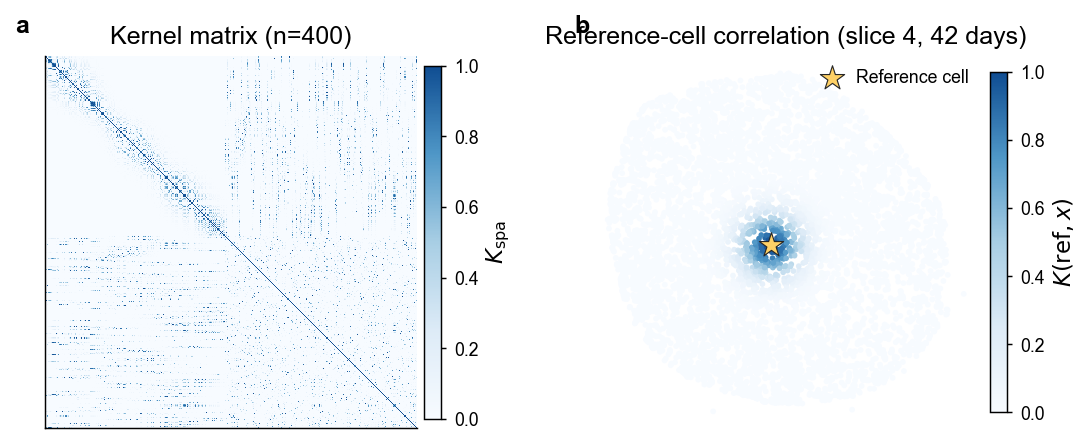

In [5]:
from plots import plot_spatial_kernel_corr_combined
fig = plot_spatial_kernel_corr_combined(
    adata=adata_immune,
    bandwidth=float(gamma_spa),
    slice_idx=5,
)

[kernel] K_age (ar1)  well-conditioned  (cond=1.61e+01)  ->  Figures/Immune_L/kernel_age_immune.png


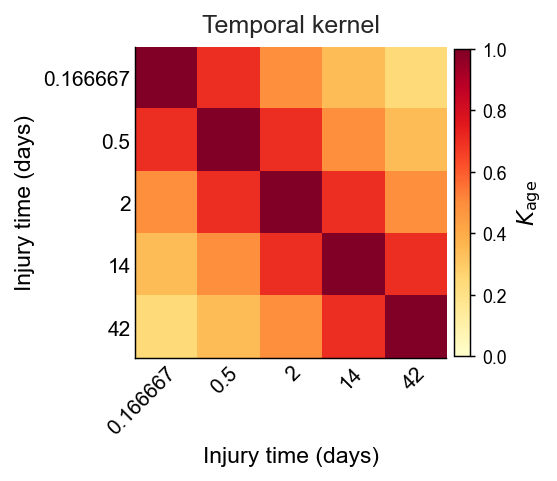

In [6]:
from plots import plot_kernel_age
fig = plot_kernel_age(
    K_age, ages, uniq_groups = "ident",
    kernel_type="ar1", celltype="immune",
    fig_dir=FIGURES_DIR,
)

In [7]:
t0 = time.perf_counter()
res = fit_pfactor(
    Y_list=Y_list, Nlist=nlist, K_age=K_age, Kspa_list=K_spa_list,
    p=3, k=15, inner_rank1_tol=1e-4, random_state=0, verbose=1,
)
print(f"Runtime: {time.perf_counter() - t0:.1f}s")

# ── Save results ─────────────────────────────────────────────────────────
res["gamma_age"] = gamma_age; res["gamma_spa"] = gamma_spa
with open(PKL_PATH, "wb") as f:
    pickle.dump(res, f)
print(f"Saved: {PKL_PATH}")

[sweep=001] dW_rel=3.686e-01 dTheta_rel=5.024e-02 time=4.389e+00
[sweep=002] dW_rel=1.581e-01 dTheta_rel=2.634e-02 time=5.498e+00
[sweep=003] dW_rel=4.555e-02 dTheta_rel=8.638e-03 time=4.160e+00
[sweep=004] dW_rel=2.922e-02 dTheta_rel=5.362e-03 time=4.061e+00
[sweep=005] dW_rel=2.166e-02 dTheta_rel=3.875e-03 time=3.855e+00
[sweep=006] dW_rel=1.682e-02 dTheta_rel=3.004e-03 time=3.531e+00
[sweep=007] dW_rel=1.341e-02 dTheta_rel=2.408e-03 time=3.233e+00
[sweep=008] dW_rel=1.089e-02 dTheta_rel=1.981e-03 time=3.094e+00
[sweep=009] dW_rel=8.984e-03 dTheta_rel=1.647e-03 time=2.972e+00
[sweep=010] dW_rel=7.496e-03 dTheta_rel=1.382e-03 time=2.873e+00
[sweep=011] dW_rel=6.310e-03 dTheta_rel=1.179e-03 time=2.662e+00
[sweep=012] dW_rel=5.356e-03 dTheta_rel=1.001e-03 time=2.616e+00
[sweep=013] dW_rel=4.568e-03 dTheta_rel=8.670e-04 time=2.832e+00
[sweep=014] dW_rel=3.924e-03 dTheta_rel=7.430e-04 time=2.434e+00
[sweep=015] dW_rel=3.373e-03 dTheta_rel=6.457e-04 time=2.193e+00
[sweep=016] dW_rel=2.924e

In [8]:
# ── Attach scores to AnnData & save ─────────────────────────────────────────
ADATA_PATH = OUT_DIR / "adata_with_scores.h5ad"

age_arr = pd.to_numeric(adata_immune.obs["age"], errors="coerce").to_numpy(float)
groups  = adata_immune.obs["ident"].astype(str).to_numpy()
uniq, inv = np.unique(groups, return_inverse=True)
idx_per_group = [np.sort(np.where(inv == t)[0]) for t in range(len(uniq))]

# Apply the same age-ascending sort used during model fitting
_ages_raw = np.array([age_arr[ix[0]] for ix in idx_per_group])
sort_ord      = np.argsort(_ages_raw)
idx_sorted    = [idx_per_group[i] for i in sort_ord]  
slices_sorted = uniq[sort_ord]                       
ages_sorted   = _ages_raw[sort_ord]                  

adata = adata_immune.copy()
all_idx = np.concatenate(idx_sorted)   # res["H"] rows follow this order
H_arr = np.empty_like(res["H"]);  H_arr[all_idx] = res["H"]
b_arr = np.empty_like(res["b"]);  b_arr[all_idx] = res["b"]
adata.obsm["X_stgp"]         = H_arr.astype(np.float32)
adata.obsm["X_stgp_spatial"] = b_arr.astype(np.float32)
adata.uns["stgp"] = dict(
    groups=slices_sorted.tolist(), ages=ages_sorted.tolist(),
    gamma_age=float(res["gamma_age"]), gamma_spa=float(res["gamma_spa"]),
    p_selected=res["W"].shape[0],
    alpha=np.asarray(res["alpha"]).tolist(),
    alpha_lower=np.asarray(res["alpha_lower"]).tolist(),
    alpha_upper=np.asarray(res["alpha_upper"]).tolist(),
    theta=np.asarray(res["theta"]).tolist(),
    sigma2e=float(res.get("sigma2e", np.nan)),
)
adata.write_h5ad(str(ADATA_PATH), compression="gzip")
print(f"Saved: {ADATA_PATH}")

# Also write W.csv for enrichment
p_sel = res["W"].shape[0]
W_df = pd.DataFrame(res["W"],
                    index=[f"stGP{j+1}" for j in range(p_sel)],
                    columns=adata.var_names.astype(str))
W_df.to_csv(OUT_DIR / "W.csv")

Saved: Results/stgp/Immune_L/adata_with_scores.h5ad


---
## 3. Loading Saved Results

The cells below reload all fitted outputs from disk so that the downstream
analysis (Section 4) can be run independently without re-fitting the model.
Skip this section if you are continuing directly from Section 2.


In [9]:
# ── Reload fitted outputs ──────────────────────────────────────────────────
ADATA_PATH = OUT_DIR / "adata_with_scores.h5ad"
adata      = sc.read_h5ad(str(ADATA_PATH))

W_df      = pd.read_csv(OUT_DIR / "W.csv", index_col=0)
stgp_info = adata.uns["stgp"]
p_sel     = stgp_info["p_selected"]
slices    = np.array(stgp_info["groups"])

W_df.index = [f"stGP{i+1}" for i in range(len(W_df))]
print(f"Loaded: {adata.n_obs} cells  |  {p_sel} programs  |  {len(slices)} slices")


Loaded: 27808 cells  |  3 programs  |  5 slices


---
## 4. Downstream Analysis

### 4.1 Gene Loadings (W matrix)

Each row of **W** is a non-negative weight vector over the measured genes.
Positive-weight genes define the molecular identity of each program; the
magnitude reflects the gene's contribution to that program.


In [10]:
W_df = pd.read_csv(OUT_DIR / "W.csv", index_col=0)
W_df.index = [f"stGP{i+1}" for i in range(len(W_df))]

print("Top 15 genes per program:")
for prog, row in W_df.iterrows():
    top = row[row > 0].sort_values(ascending=False).head(15)
    print(f"  {prog}: {', '.join(top.index.tolist())}")

Top 15 genes per program:
  stGP1: Cd74, Akap12, Krt20, Timp3, Fosl1, Serpine1, Tagln, Acsm3, Plin2, Csf1, Havcr1, Mcam, Gsta1, Cxcl1, Ngf
  stGP2: Cd74, Mgp, Cxcl12, Sfrp1, Acsm3, Smoc2, Mmp2, Ccl8, Col1a1, Spon1, Slc12a1, C3, Il2rb, Ptger1, Nrp1
  stGP3: Ccr1, Spp1, Acta2, Plin2, Ccl7, Cd44, Bst1, Calm1, Tagln, Tgfb1, Tnfrsf11a, Calr, Calm2, Wnk1, Calm3


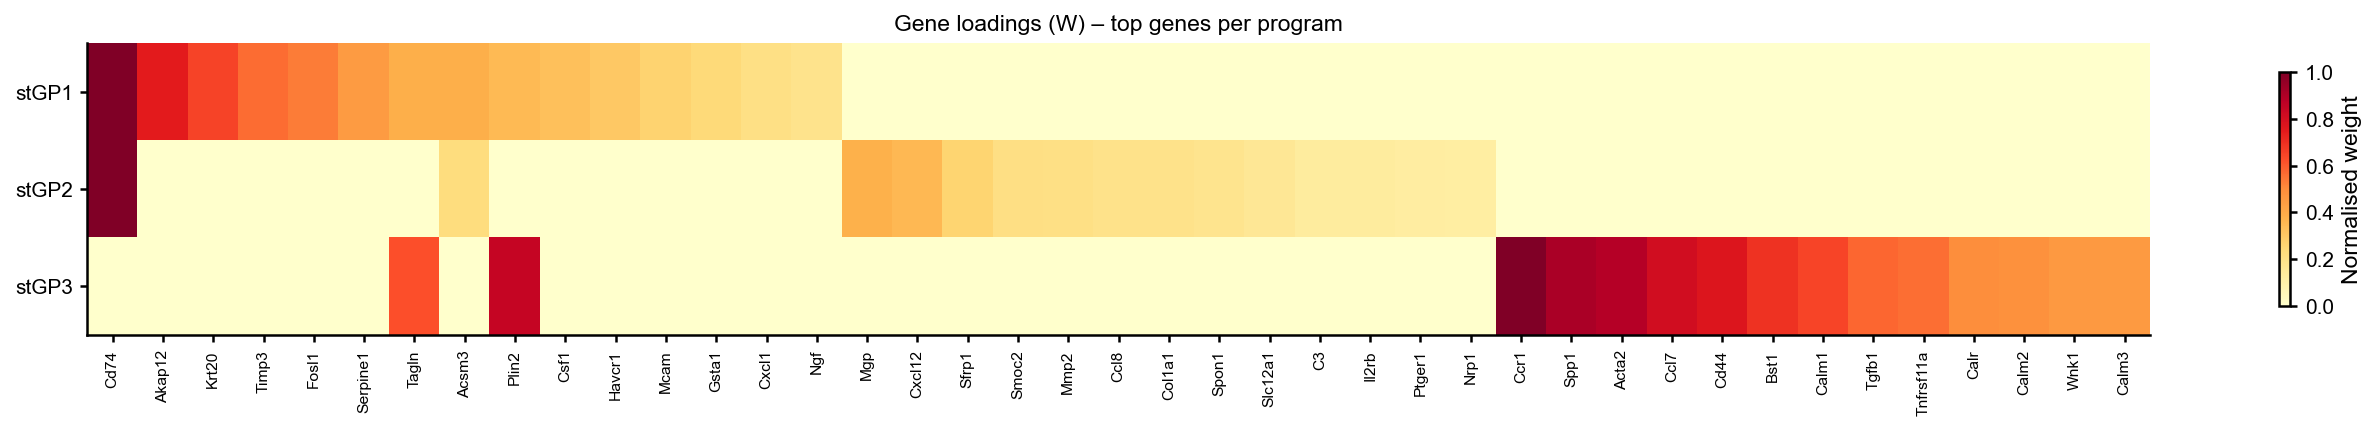

In [11]:
n_top = 15
top_genes_per_prog = []
for _, row in W_df.iterrows():
    top_genes_per_prog.extend(row[row > 0].sort_values(ascending=False).head(n_top).index.tolist())
top_genes = list(dict.fromkeys(top_genes_per_prog))  # preserve order, deduplicate

W_sub = W_df[top_genes]
# Normalise each row to [0, 1] for visualisation
W_norm = W_sub.div(W_sub.max(axis=1) + 1e-12, axis=0)

fig, ax = plt.subplots(figsize=(min(0.4 * len(top_genes) + 2, 18), 3))
im = ax.imshow(W_norm.values, aspect="auto", cmap="YlOrRd", vmin=0, vmax=1)
ax.set_yticks(range(len(W_df))); ax.set_yticklabels(W_df.index)
ax.set_xticks(range(len(top_genes)))
ax.set_xticklabels(top_genes, rotation=90, fontsize=7.5)
ax.set_title("Gene loadings (W) – top genes per program", fontsize=11)
plt.colorbar(im, ax=ax, shrink=0.8, label="Normalised weight")
plt.tight_layout()
plt.show()

### 4.2 Spatial Gene-Program Maps

The **spatial field b** captures the within-slice smooth variation of each program.
We tile all tissue sections ordered by donor age so any age-related spatial patterns
become visible.

In [12]:
from plots import plot_stgp_spatial_programs

scores_df = pd.DataFrame(
    adata.obsm["X_stgp_spatial"],
    index=adata.obs_names,
    columns=[f"stGP{j+1}" for j in range(p_sel)],
)

figs = plot_stgp_spatial_programs(
    stgp_adata=adata, scores=scores_df,
    celltype="Immune",
    ncols=5, fg_dot_size=5.0, dpi=300,
)
for j, fig in enumerate(figs):
    fig.subplots_adjust(top=0.85)
    fig.suptitle('Left Kidney', fontsize=13)
    fig.savefig(FIGURES_DIR / f"spatial_stGP{j+1}.png", dpi=300, bbox_inches="tight")
    plt.close(fig)


### 4.4 Age Trajectories (α)

**α(t)** is the posterior mean age effect of each program — it quantifies how the
program amplitude changes across the human lifespan (15–87 yr).
The shaded band shows the 95% posterior credible interval.

Saved alpha trajectory figures → Figures/Immune_L


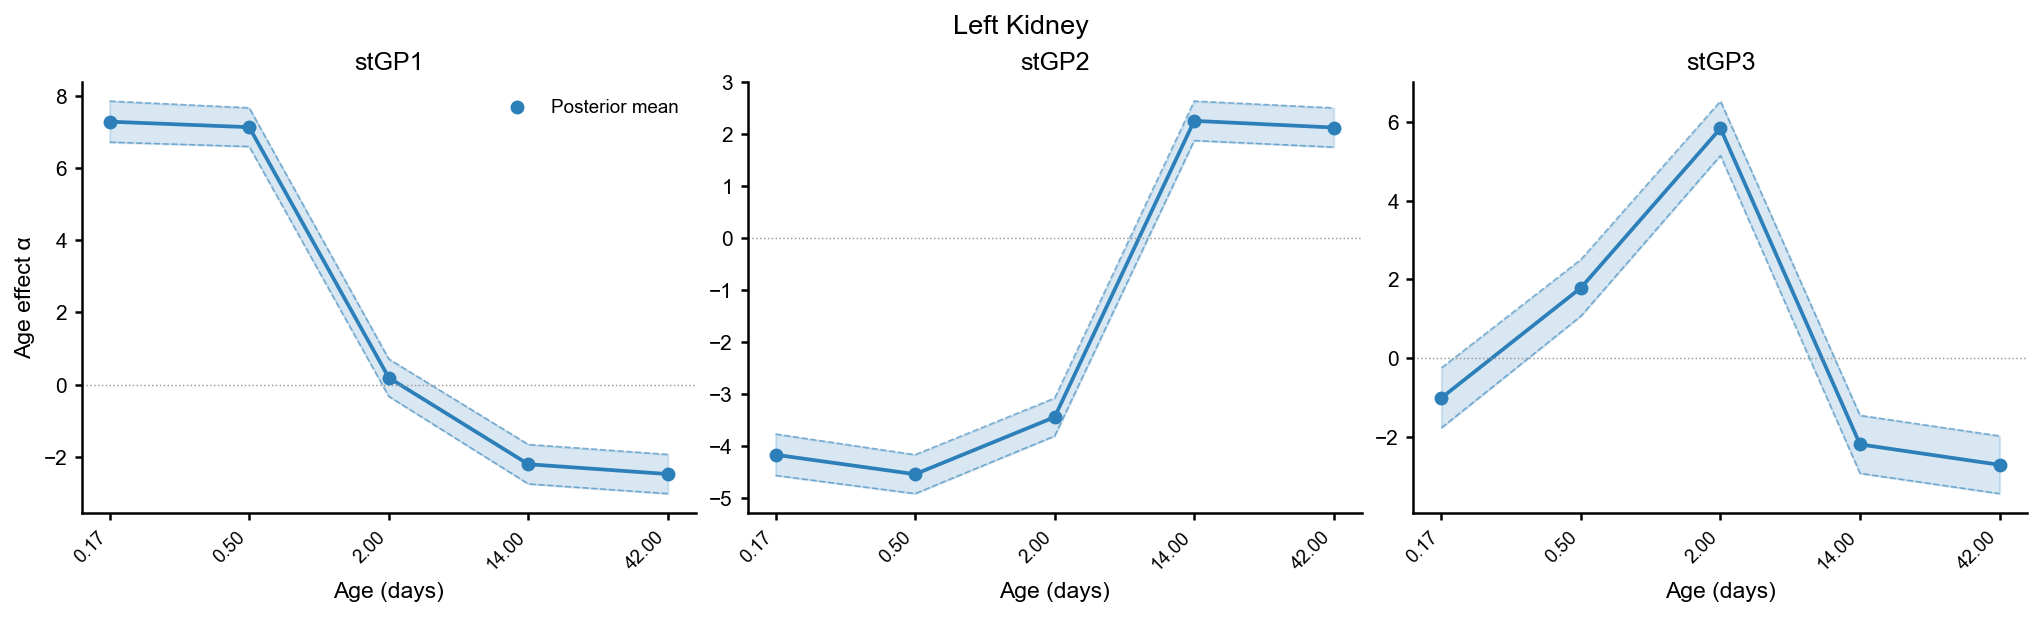

In [13]:
stgp_info   = adata.uns['stgp']
ages_slices = np.array(stgp_info['ages'])
alpha       = np.array(stgp_info['alpha'])        # (p, n_slices)
alpha_lower = np.array(stgp_info['alpha_lower'])
alpha_upper = np.array(stgp_info['alpha_upper'])

COLOR = '#2C7FB8'
fig, axes = plt.subplots(1, p_sel, figsize=(4.5 * p_sel, 4), constrained_layout=True)
for j, ax in enumerate(np.atleast_1d(axes)):
    order = np.argsort(ages_slices)
    t_idx = np.arange(len(order))  # 均匀分布的索引
    t_ages = ages_slices[order]     # 真实的年龄值
    a  = alpha[j][order]
    lo = alpha_lower[j][order]
    hi = alpha_upper[j][order]
    ax.fill_between(t_idx, lo, hi, alpha=0.18, color=COLOR)
    ax.plot(t_idx, lo, lw=0.8, ls='--', color=COLOR, alpha=0.55)
    ax.plot(t_idx, hi, lw=0.8, ls='--', color=COLOR, alpha=0.55)
    ax.plot(t_idx, a,  lw=1.8, color=COLOR)
    ax.scatter(t_idx, a, s=32, color=COLOR, zorder=3,
               label='Posterior mean' if j == 0 else '')
    ax.axhline(0, color='0.6', lw=0.7, ls=':')
    ax.set_title(f'stGP{j+1}', fontsize=12)
    ax.set_xticks(t_idx)
    ax.set_xticklabels([f'{age:.2f}' for age in t_ages], rotation=45, ha='right', fontsize=9)
    ax.set_xlabel('Age (days)')
    ax.set_ylabel('Age effect α' if j == 0 else '')
    if j == 0:
        ax.legend(fontsize=9)

fig.suptitle('Left Kidney', fontsize=13)
fig.savefig(FIGURES_DIR / "alpha_trajectories.png", dpi=400, bbox_inches="tight")
print(f"Saved alpha trajectory figures → {FIGURES_DIR}")

### 4.5 GP Parameters (θ)

For each program, **θ = [amplitude, noise_fraction]** describes the relative strength of
the spatial GP component versus cell-intrinsic noise.
A high amplitude with low noise fraction indicates a strongly spatially structured program.

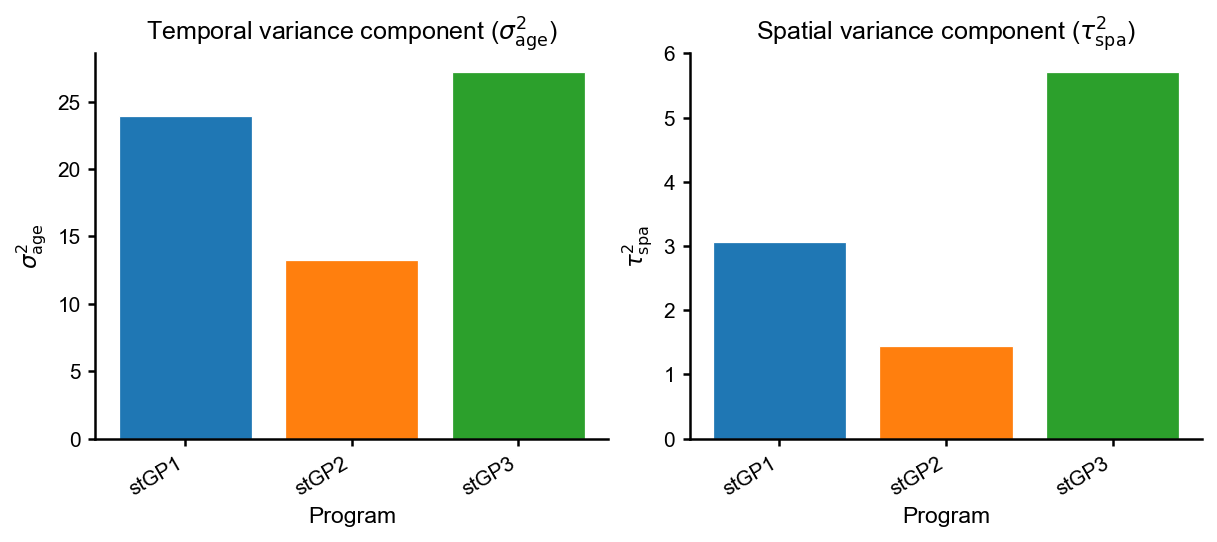

In [14]:
theta      = np.array(stgp_info['theta'])   # (p, 2): [amplitude, noise_frac]
prog_names = [f'stGP{j+1}' for j in range(p_sel)]
prog_colors = plt.cm.tab10.colors[:p_sel]

fig, axes = plt.subplots(1, 2, figsize=(8, 3.5), constrained_layout=True)

for j, (col, name) in enumerate(zip(prog_colors, prog_names)):
    axes[0].bar(j, theta[j, 0], color=col, edgecolor='white', linewidth=0.6)
    axes[1].bar(j, theta[j, 1], color=col, edgecolor='white', linewidth=0.6)

for ax in axes:
    ax.set_xticks(range(p_sel))
    ax.set_xticklabels(prog_names, rotation=30, ha='right')
    ax.set_xlabel('Program')

axes[0].set_ylabel(r'$\sigma_{\mathrm{age}}^2$')
axes[0].set_title(r'Temporal variance component ($\sigma_{\mathrm{age}}^2$)')
axes[1].set_ylabel(r'$\tau_{\mathrm{spa}}^2$')
axes[1].set_title(r'Spatial variance component ($\tau_{\mathrm{spa}}^2$)')

fig.savefig(FIGURES_DIR / "theta_barplot.png", dpi=400, bbox_inches="tight")

### 4.6 Spatial Visualisation of a Single Slice

We inspect one tissue slice in detail, showing the **spatial b field** of each program
(the smooth within-slice component).

Visualising slice: Day14L  (age 14 day, n=9011 cells)


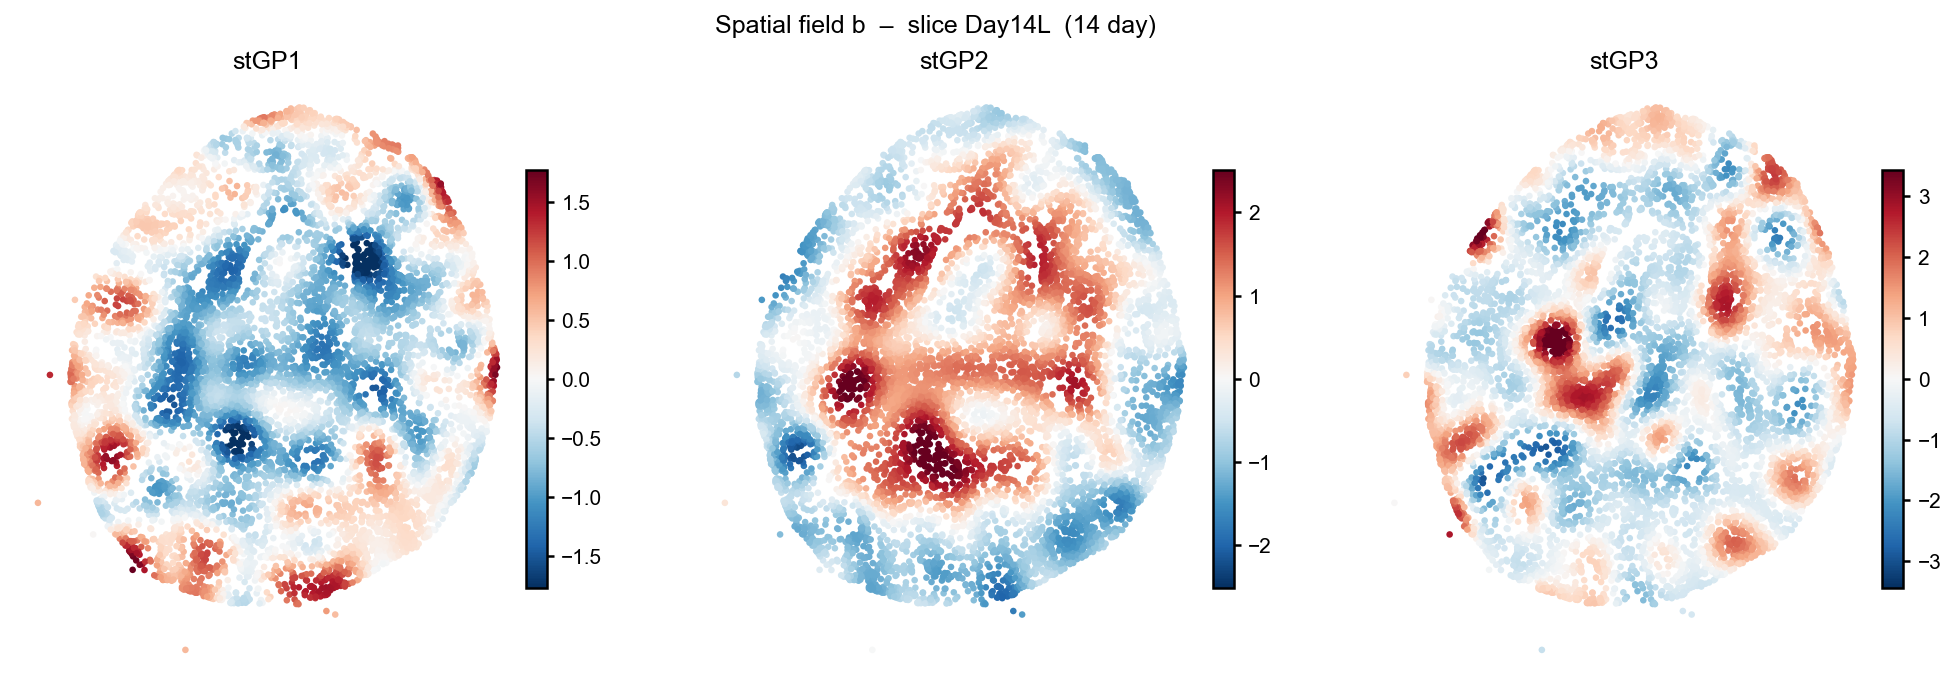

In [15]:
# Pick a mid-age slice
example_slice = 'Day14L'
sub     = adata[adata.obs['ident'] == example_slice].copy()
age_val = sub.obs['injury_time_days'].iloc[0]
print(f'Visualising slice: {example_slice}  (age {age_val:.0f} day, n={sub.n_obs} cells)')

fig, axes = plt.subplots(1, p_sel, figsize=(4.5 * p_sel, 4.5), constrained_layout=True)
b  = sub.obsm['X_stgp_spatial']
xy = np.asarray(sub.obsm['spatial'])
for j, ax in enumerate(np.atleast_1d(axes)):
    v99 = np.nanpercentile(np.abs(b[:, j]), 99)
    sc_ref = ax.scatter(xy[:, 0], xy[:, 1], c=b[:, j],
                        cmap='RdBu_r', vmin=-v99, vmax=v99,
                        s=10, linewidths=0, rasterized=True)
    ax.set_aspect('equal'); ax.axis('off')
    ax.set_title(f'stGP{j+1}')
    plt.colorbar(sc_ref, ax=ax, shrink=0.7, pad=0.01)

fig.suptitle(f'Spatial field b  –  slice {example_slice}  ({age_val:.0f} day)', fontsize=12)
fig.savefig(FIGURES_DIR / f"spatial_b_{example_slice}.png", dpi=400, bbox_inches="tight")

In [16]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.spatial import cKDTree
from scipy.stats import pearsonr, spearmanr
from statsmodels.stats.multitest import multipletests
import warnings, os
warnings.filterwarnings("ignore", category=FutureWarning)
import sys
sys.path.insert(0, os.path.join(".."))

import re
import textwrap

# ── term-name cleanup ────────────────────────────────────────────────────────
# Pathway sources (Hallmark / GO / Reactome / KEGG / WikiPathways)
_PATHWAY_PREFIXES = ("GOBP", "GOCC", "GOMF", "HALLMARK", "REACTOME", "KEGG", "WP")

# M8 cell-atlas sources (longest prefix matched first)
_M8_SOURCE_PREFIXES = (
    "TABULA_MURIS_SENIS_",
    "TABULA_MURIS_",
    "DESCARTES_ORGANOGENESIS_",
    "DESCARTES_FETAL_",
    "DESCARTES_MAIN_FETAL_",
    "DESCARTES_",
    "ZHANG_",
)

# Common abbreviations to restore (case-insensitive whole-word matching)
_ABBREV = (
    (r"\bdna\b",      "DNA"),
    (r"\brna\b",      "RNA"),
    (r"\bmrna\b",     "mRNA"),
    (r"\bt cell\b",   "T cell"),
    (r"\bb cell\b",   "B cell"),
    (r"\bnk cell\b",  "NK cell"),
    (r"\bmhc\b",      "MHC"),
    (r"\btnf\b",      "TNF"),
    (r"\bifn\b",      "IFN"),
    (r"\bil(?=[-\s\d])", "IL"),    # IL-1, IL 6, IL2 …
    (r"\bhif(?=[-\s\d])", "HIF"),  # HIF-1, HIF1 …
    (r"\bopc\b",      "OPC"),
    (r"\bcns\b",      "CNS"),
    (r"\bkras\b",     "KRAS"),
    (r"\begfr\b",     "EGFR"),
    (r"\btp53\b",     "TP53"),
    (r"\bnf-?kb\b",   "NF-κB"),
    # Roman-numeral classes / types (e.g. "class i" -> "class I",
    # "MHC class ib" -> "MHC class Ib", "type iia" -> "type IIa")
    (r"\b(class|type|stage)\s+(i{1,3}|iv|v|vi{0,3}|ix|x)([ab]?)\b",
     lambda m: f"{m.group(1)} {m.group(2).upper()}{m.group(3)}"),
)

# Tissue/adjective synonyms — collapse pairs like "Lung pulmonary" -> "Lung",
# "Pancreas pancreatic" -> "Pancreas", "Kidney kidney" -> "Kidney".
_TISSUE_SYN = (
    ("lung",     "pulmonary"),
    ("pancreas", "pancreatic"),
    ("kidney",   "renal"),
    ("heart",    "cardiac"),
    ("liver",    "hepatic"),
    ("brain",    "cerebral"),
    ("colon",    "colonic"),
    ("stomach",  "gastric"),
    ("muscle",   "muscular"),
    ("bone",     "osseous"),
)
_SYN_MAP = {b: a for a, b in _TISSUE_SYN}
_SYN_MAP.update({a: b for a, b in _TISSUE_SYN})

def _dedupe_words(s: str) -> str:
    """Drop adjacent duplicate / synonymous words ('kidney kidney …', 'lung pulmonary …')."""
    out: list[str] = []
    for w in s.split():
        wl = w.lower()
        if out and (out[-1].lower() == wl or _SYN_MAP.get(out[-1].lower()) == wl):
            continue
        out.append(w)
    return " ".join(out)


def clean_term(term: str, width: int | None = None) -> str:
    """Pretty-print MSigDB-style term IDs (Hallmark / GO / Reactome / M8)."""
    s = str(term)

    # 1) strip pathway-source prefix (Hallmark / GO_BP / Reactome / …)
    s = re.sub(rf"^(?:{'|'.join(_PATHWAY_PREFIXES)})_", "", s)

    # 2) strip cell-atlas source prefix (Tabula Muris / Descartes / Zhang)
    for p in _M8_SOURCE_PREFIXES:
        if s.startswith(p):
            s = s[len(p):]
            break

    # 3) strip uninformative direction suffixes (keep _AGEING — important for analysis)
    s = re.sub(r"_(UP|DN|DOWN)$", "", s)

    # 4) underscores -> spaces, sentence case
    s = s.replace("_", " ").strip()
    s = _dedupe_words(s)
    s = s.lower().capitalize()

    # 5) restore common abbreviations
    for pat, repl in _ABBREV:
        s = re.sub(pat, repl, s, flags=re.IGNORECASE)

    if width is not None:
        s = "\n".join(textwrap.wrap(s, width=width))
    return s


In [17]:
# CN enrichment of high spatial stGP activity
# For each immune program, test whether top-5% spatial cells are enriched in each CN.
from scipy.stats import fisher_exact
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

NM_W_FULL = 180 / 25.4

def short_cn(label):
    return str(label).split(": ", 1)[0]

spatial_scores = np.asarray(adata.obsm["X_stgp"])
prog_names = [f"stGP{j+1}" for j in range(spatial_scores.shape[1])]
score_cols = []
for j, prog in enumerate(prog_names):
    col = prog.replace(" ", "_") + "_spatial"
    adata.obs[col] = spatial_scores[:, j]
    score_cols.append(col)

cn_order = list(adata.obs["CN"].cat.categories) if hasattr(adata.obs["CN"], "cat") else sorted(adata.obs["CN"].dropna().unique())
cn_short = [short_cn(x) for x in cn_order]

cn_rows = []
for prog, col in zip(prog_names, score_cols):
    x = adata.obs[col].astype(float)
    high = x >= x.quantile(0.95)
    for cn in cn_order:
        in_cn = adata.obs["CN"].astype(str).eq(str(cn))
        a = int((high & in_cn).sum())
        b = int((~high & in_cn).sum())
        c = int((high & ~in_cn).sum())
        d = int((~high & ~in_cn).sum())
        odds, pval = fisher_exact([[a, b], [c, d]], alternative="greater")

        x_cn = x.loc[in_cn].to_numpy()
        x_rest = x.loc[~in_cn].to_numpy()
        _, p_mwu = mannwhitneyu(x_cn, x_rest, alternative="greater")
        
        cn_rows.append({
            "program": prog,
            "score_col": col,
            "CN": str(cn),
            "CN_short": short_cn(cn),
            "n_cn": int(in_cn.sum()),
            "n_high_in_cn": a,
            "frac_high_in_cn": a / max(a + b, 1),
            "frac_high_outside": c / max(c + d, 1),
            "odds_ratio": odds,
            "fisher_pval": pval,
            "mean_score_cn": float(x_cn.mean()) if len(x_cn) else np.nan,
            "mean_score_rest": float(x_rest.mean()) if len(x_rest) else np.nan,
            "delta_mean_score": float(x_cn.mean() - x_rest.mean()) if len(x_cn) and len(x_rest) else np.nan,
            "mwu_pval": p_mwu,
        })

cn_enrich = pd.DataFrame(cn_rows)
cn_enrich["fisher_padj"] = multipletests(cn_enrich["fisher_pval"], method="fdr_bh")[1]
valid_mwu = cn_enrich["mwu_pval"].notna()
cn_enrich["mwu_padj"] = multipletests(cn_enrich["mwu_pval"], method="fdr_bh")[1]
cn_enrich["log2_or"] = np.log2(cn_enrich["odds_ratio"].replace(np.inf, np.nan)).fillna(5).clip(-4, 5)
cn_enrich["neglog10_fdr"] = -np.log10(cn_enrich["fisher_padj"].clip(lower=1e-300))
cn_enrich.to_csv(OUT_DIR / "immune_stgp_top_decile_CN_enrichment.csv", index=False)

# Heatmap matrices.
log2_or_mat = (
    cn_enrich.pivot(index="program", columns="CN", values="log2_or")
    .reindex(index=prog_names, columns=cn_order)
)
frac_mat = (
    cn_enrich.pivot(index="program", columns="CN", values="frac_high_in_cn")
    .reindex(index=prog_names, columns=cn_order)
)
fdr_mat = (
    cn_enrich.pivot(index="program", columns="CN", values="fisher_padj")
    .reindex(index=prog_names, columns=cn_order)
)
fdr_mwu_mat = (
    cn_enrich.pivot(index="program", columns="CN", values="mwu_padj")
    .reindex(index=prog_names, columns=cn_order)
)

/home/byual/.conda/envs/stGP/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


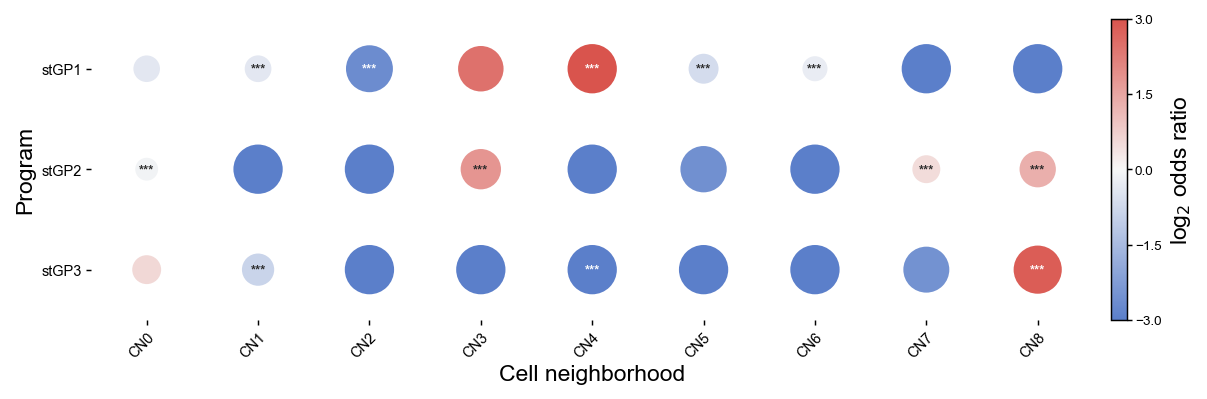

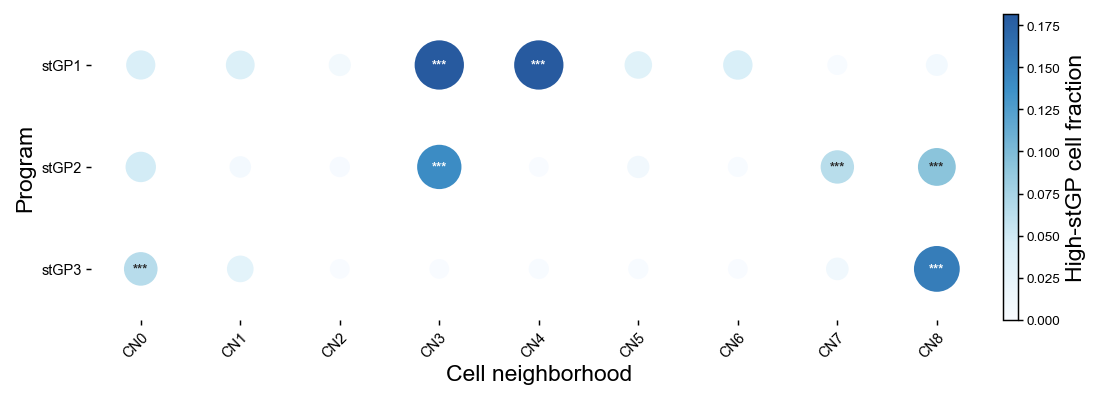

In [18]:
from matplotlib.colors import LinearSegmentedColormap, Normalize, TwoSlopeNorm

muted_or_cmap = LinearSegmentedColormap.from_list(
    "muted_log2_or", ["#5B7FCA", "#F7F7F7", "#D9544D"], N=256
)
soft_fraction_cmap = LinearSegmentedColormap.from_list(
    "soft_high_stgp_fraction", ["#F8FBFF", "#D7EEF7", "#8EC6DC", "#3E91C8", "#275A9F"], N=256
)


def sig_label(q):
    if not np.isfinite(q):
        return ""
    if q < 0.001:
        return "***"
    if q < 0.01:
        return "**"
    if q < 0.05:
        return "*"
    return ""


def style_heatmap_axis(ax, n_rows, n_cols):
    ax.set_xlim(-0.5, n_cols - 0.5)
    ax.set_ylim(n_rows - 0.5, -0.5)
    ax.set_xticks(np.arange(n_cols))
    ax.set_xticklabels(cn_short, rotation=45, ha="right", rotation_mode="anchor")
    ax.set_yticks(np.arange(n_rows))
    ax.set_yticklabels(prog_names)
    ax.set_xlabel("Cell neighborhood", labelpad=2)
    ax.set_ylabel("Program", labelpad=3)
    ax.grid(False)
    ax.tick_params(axis="both", labelsize=7, pad=2, length=2.5, width=0.7)
    for spine in ax.spines.values():
        spine.set_visible(False)


def circle_sizes(values, vmax, min_size=95, max_size=520):
    scaled = np.clip(np.abs(values) / vmax, 0, 1)
    return min_size + (max_size - min_size) * scaled


def plot_circle_heatmap(ax, mat, *, cmap, norm, size_values=None, size_vmax=None, min_size=95, max_size=520):
    values = mat.to_numpy(dtype=float)
    rows, cols = np.indices(values.shape)
    mask = np.isfinite(values)
    if size_values is None:
        size_values = values
    if size_vmax is None:
        size_vmax = np.nanmax(np.abs(size_values))
    sizes = circle_sizes(size_values, size_vmax, min_size=min_size, max_size=max_size)
    return ax.scatter(
        cols[mask],
        rows[mask],
        c=values[mask],
        s=sizes[mask],
        cmap=cmap,
        norm=norm,
        marker="o",
        edgecolors="none",
        linewidths=0,
        zorder=3,
    )


def annotate_significance(ax, q_mat, value_mat, white_threshold):
    for i in range(q_mat.shape[0]):
        for j in range(q_mat.shape[1]):
            label = sig_label(float(q_mat.iloc[i, j]))
            if not label:
                continue
            value = float(value_mat.iloc[i, j])
            color = "white" if np.isfinite(value) and abs(value) >= white_threshold else "#272727"
            ax.text(j, i, label, ha="center", va="center", fontsize=6.4, fontweight="bold", color=color, zorder=4)


# Enrichment effect size: color is log2 odds ratio; circle size is absolute effect size.
fig, ax0 = plt.subplots(figsize=(NM_W_FULL * 1.12, 2.55), constrained_layout=True)
norm_or = TwoSlopeNorm(vmin=-3, vcenter=0, vmax=3)
sc0 = plot_circle_heatmap(
    ax0,
    log2_or_mat,
    cmap=muted_or_cmap,
    norm=norm_or,
    size_values=np.abs(log2_or_mat.to_numpy(dtype=float)),
    size_vmax=3,
    min_size=105,
    max_size=560,
)
style_heatmap_axis(ax0, len(prog_names), len(cn_order))
annotate_significance(ax0, fdr_mwu_mat, log2_or_mat, white_threshold=1.8)
cbar0 = fig.colorbar(sc0, ax=ax0, fraction=0.035, pad=0.018, ticks=[-3, -1.5, 0, 1.5, 3])
cbar0.set_label(r"log$_2$ odds ratio", labelpad=3)
cbar0.ax.tick_params(labelsize=6.5, length=2.5, width=0.7, pad=1.5)
cbar0.outline.set_linewidth(0.7)
fig.savefig(FIGURES_DIR / "stGP_CN_top5_enrichment_log2_or.png", dpi=400, bbox_inches="tight")
plt.show()

# Abundance view: color and circle size encode the fraction of cells in each CN that fall in the top 5%.
frac_vmax = max(0.15, float(np.nanpercentile(frac_mat.values, 95)))
fig, ax1 = plt.subplots(figsize=(NM_W_FULL * 1.02, 2.55), constrained_layout=True)
sc1 = plot_circle_heatmap(
    ax1,
    frac_mat,
    cmap=soft_fraction_cmap,
    norm=Normalize(vmin=0, vmax=frac_vmax),
    size_values=frac_mat.to_numpy(dtype=float),
    size_vmax=frac_vmax,
    min_size=90,
    max_size=560,
)
style_heatmap_axis(ax1, len(prog_names), len(cn_order))
annotate_significance(ax1, fdr_mat, frac_mat, white_threshold=0.68 * frac_vmax)
cbar1 = fig.colorbar(sc1, ax=ax1, fraction=0.04, pad=0.018)
cbar1.set_label("High-stGP cell fraction", labelpad=3)
cbar1.ax.tick_params(labelsize=6.5, length=2.5, width=0.7, pad=1.5)
cbar1.outline.set_linewidth(0.7)
fig.savefig(FIGURES_DIR / "stGP_CN_top5_high_score_fraction.png", dpi=400, bbox_inches="tight")
plt.show()